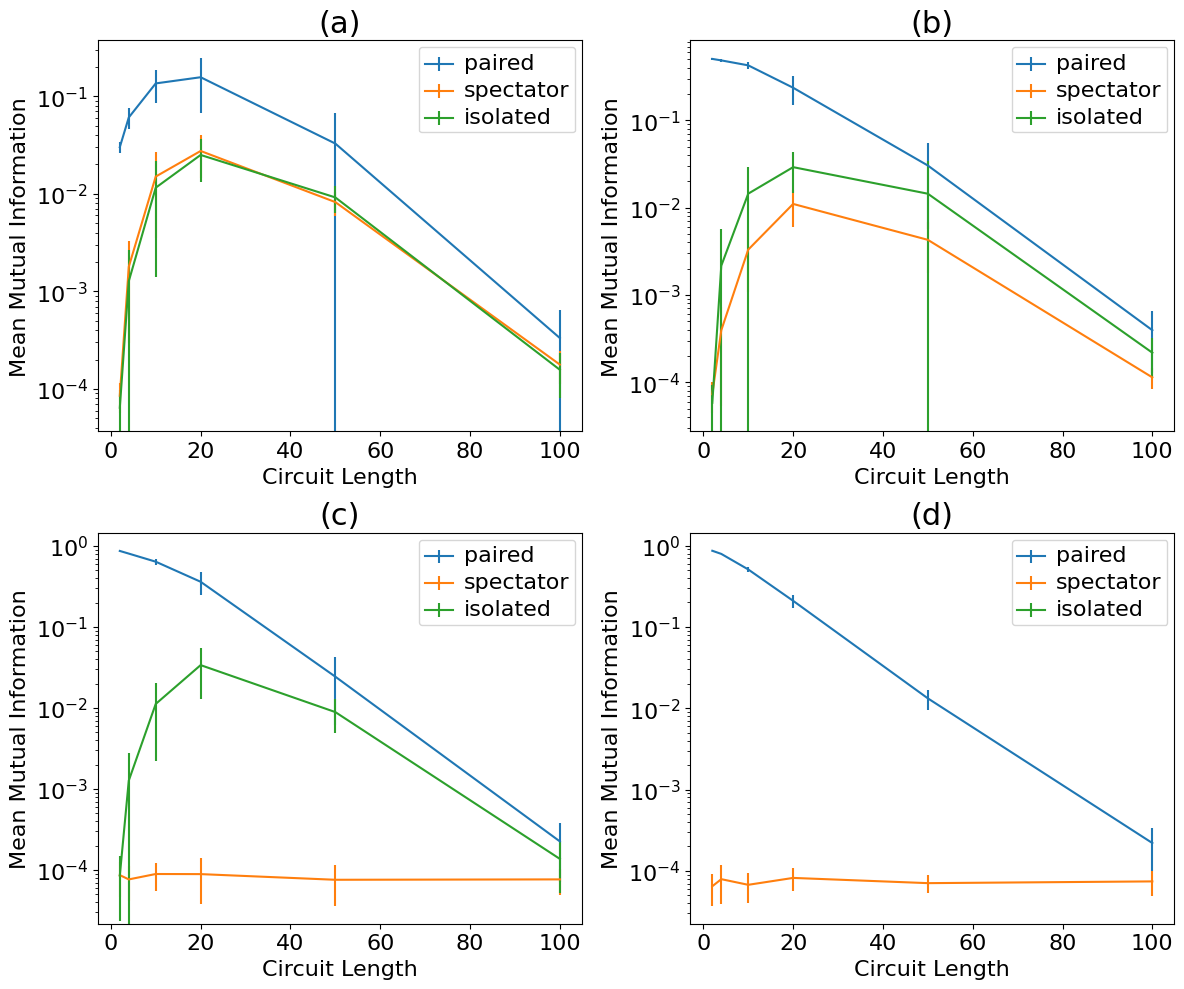

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


data_files = [
    "mmi_data_null_angle.csv",
    "mmi_data_pi_over_4.csv",
    "mmi_data_pi_over_2.csv",
    "mmi_data_pi_over_2_density_1.csv",
]

titles = [
    "(a)",
    "(b)",
    "(c)",
    "(d)",
]

dfs = [pd.read_csv(file) for file in data_files]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

for ax, df, title in zip(axs.flat, dfs, titles):

    ax.errorbar(
        df["lengths"],
        df["mmi_paired"],
        yerr=df["mmi_paired_err"],
        label="paired",
    )

    ax.errorbar(
        df["lengths"],
        df["mmi_unpaired"],
        yerr=df["mmi_unpaired_err"],
        label="spectator",
    )

    ax.errorbar(
        df["lengths"],
        df["mmi_singles"],
        yerr=df["mmi_singles_err"],
        label="isolated",
    )

    ax.set_yscale("log")
    ax.legend()

    ax.set_xlabel("Circuit Length")
    ax.set_ylabel("Mean Mutual Information")
    ax.set_title(title)

    ax.title.set_fontsize(22)
    ax.xaxis.label.set_fontsize(16)
    ax.yaxis.label.set_fontsize(16)
    ax.tick_params(axis="both", which="major", labelsize=16)

    legend = ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(16)

plt.subplots_adjust(wspace=0.7, hspace=0.5)
plt.tight_layout()
plt.savefig("noisy_backend_angle_subplots.png", dpi=300, bbox_inches="tight")
plt.show()